# ARTI404 – Image Processing
## Lab 4
#### **Student name:**  Abdulsamad Tuhaysha
#### **ID:** 2240001093



# Part A – Procedural Tasks

## Task 1: Thresholding
**Step 1:** Apply thresholding with a fixed threshold on an image.

> The manual loads `../images/Parrot.png`. That file was not provided, so the code uses it if it exists and otherwise falls back to the built-in `skimage.data.camera()` image. `cv2.imshow` is replaced by Matplotlib so the results display inline in Jupyter.

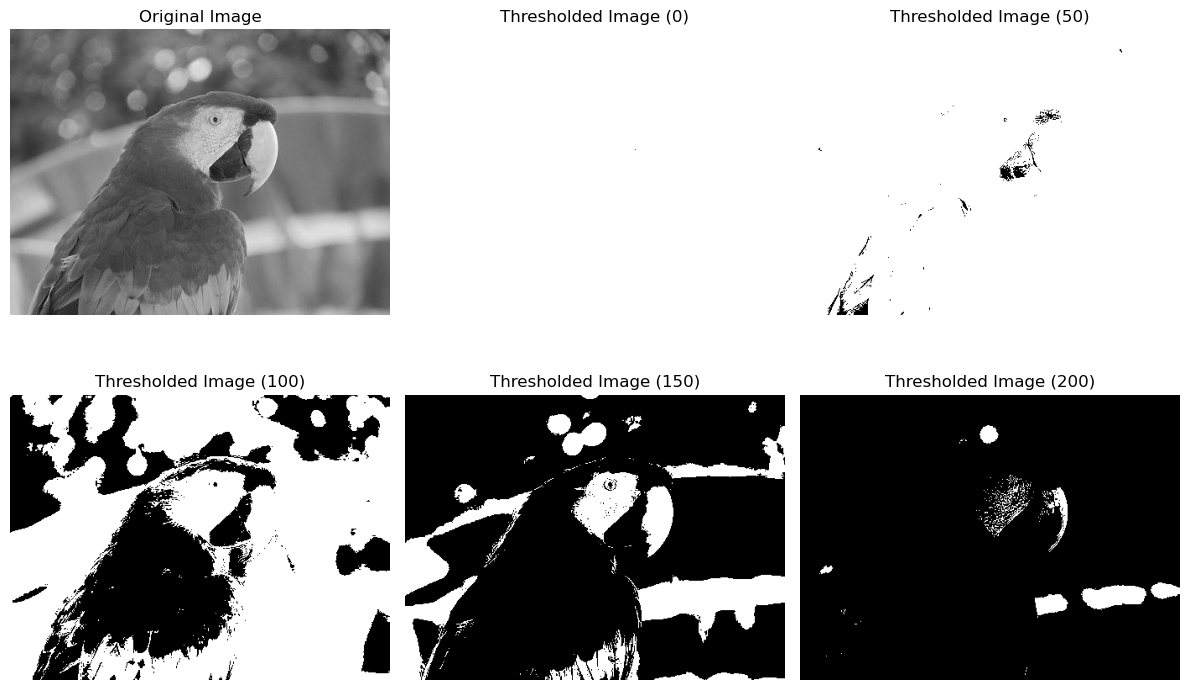

In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, img_as_ubyte, exposure

path = './Parrot.png'
img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE) if os.path.exists(path) else None
if img_gray is None:
    print('Parrot.png not found -> using skimage.data.camera() instead')
    img_gray = data.camera()

threshold_values = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image')
for ax, t in zip(axes[1:], threshold_values):
    ret, thresh = cv2.threshold(img_gray, t, 255, cv2.THRESH_BINARY)
    ax.imshow(thresh, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Thresholded Image ({t})')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observation:** With threshold 0 almost every pixel becomes white (foreground). As the threshold rises, more pixels fall below it and turn black, so only the brightest regions survive at 200.

## Task 2: Histogram Processing
**Step 1:** Load necessary libraries

In [15]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

**Step 2:** Load moon image

In [16]:
img = data.moon()
print(img.shape, img.dtype, img.min(), img.max())

(512, 512) uint8 0 255


**Step 3:** Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles (contrast stretching)

In [17]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
print('p2 =', p2, ' p98 =', p98)

p2 = 78.0  p98 = 129.0


**Step 4:** Display the image with its histogram for Step 2 and Step 3

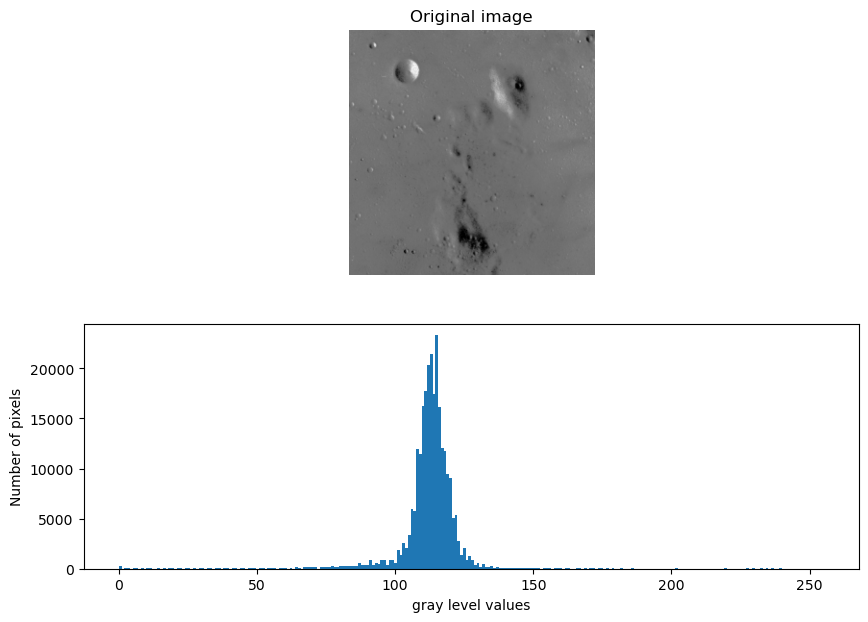

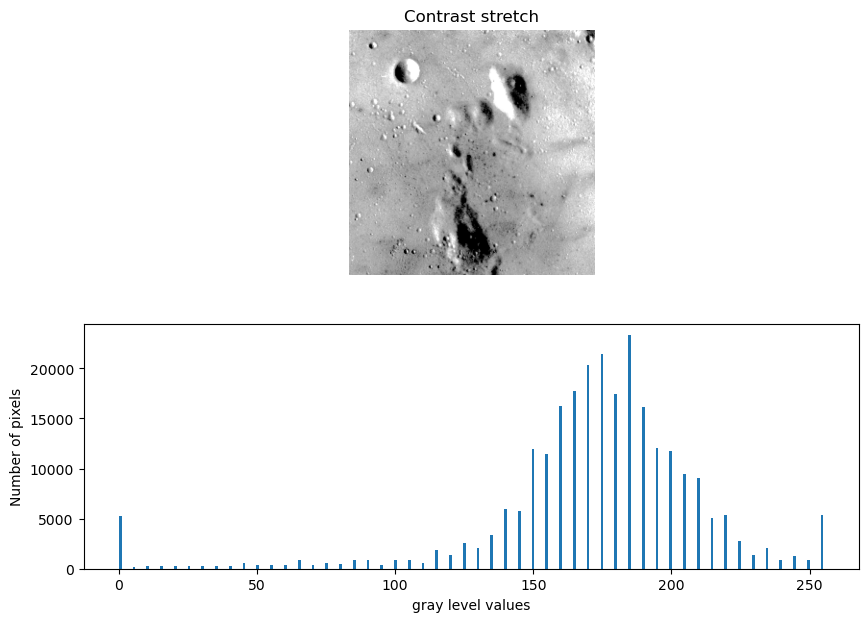

In [18]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Part B – Assessment Tasks

## Task 1: Contrast stretching with the 3rd and 80th percentiles (moon image)

p3 = 87.0, p80 = 118.0


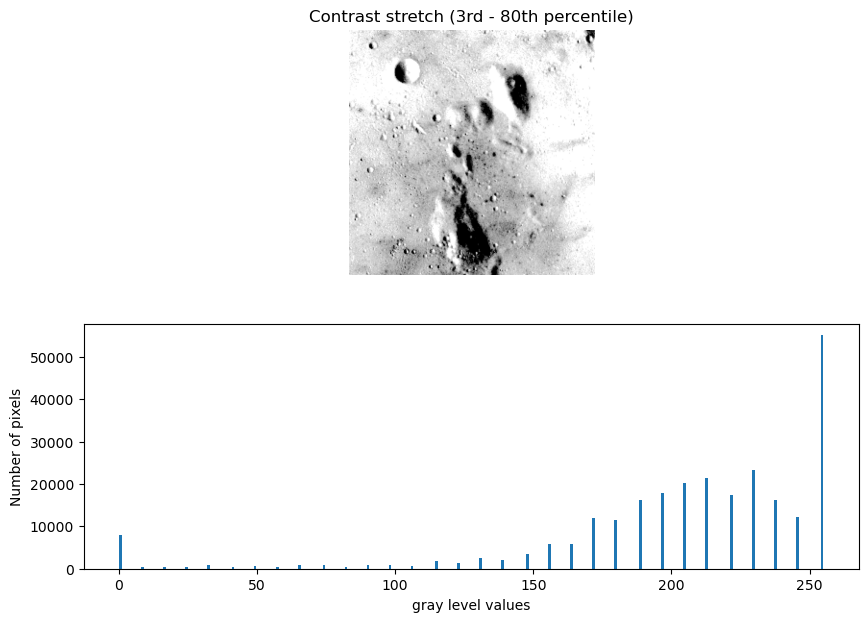

In [19]:
p3, p80 = np.percentile(img, (3, 80))
print(f'p3 = {p3}, p80 = {p80}')
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd - 80th percentile)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

**Observation:** Using the 80th percentile as the upper limit clips the brightest 20% of pixels to white, so a large spike appears at 255 and the image looks brighter and more saturated than the 2–98 stretch. The lowest 3% are clipped to black. The intensities in between are spread over the full 0–255 range.

## Task 2: Histogram equalization with `exposure.equalize_hist` (moon image)

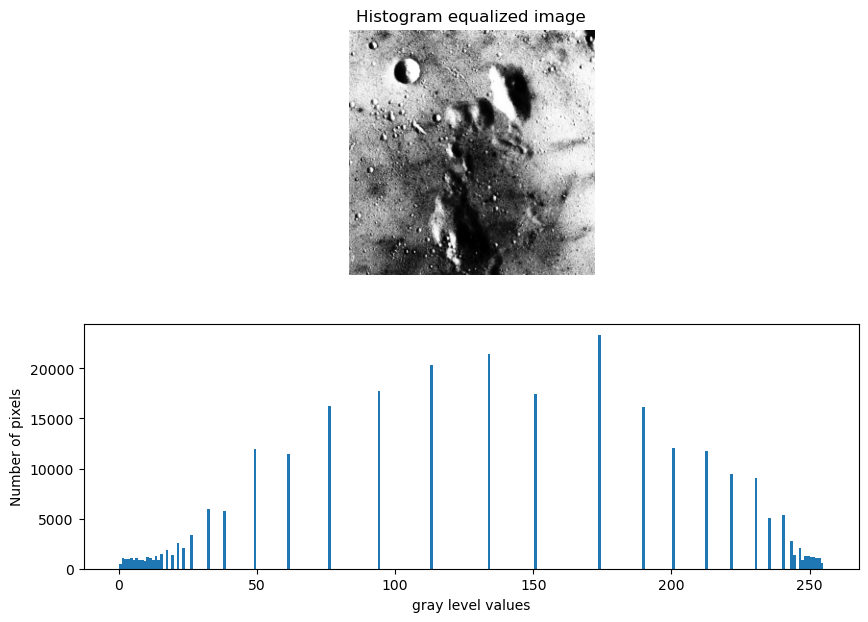

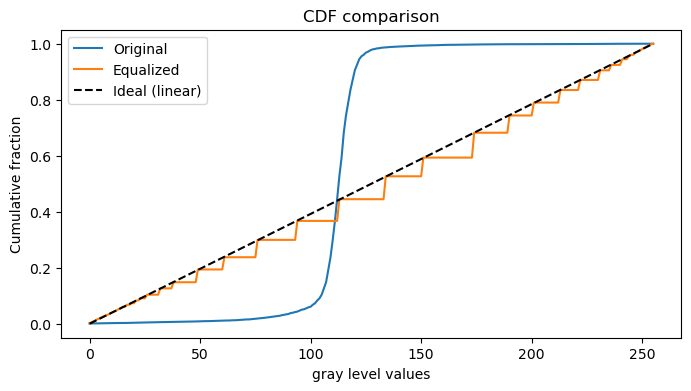

In [20]:
img_eq = exposure.equalize_hist(img)          # float image in [0, 1]
img_eq_u8 = img_as_ubyte(img_eq)              # back to 0-255 for a comparable histogram

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram equalized image')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq_u8.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Cumulative distributions: original vs equalized
cdf_o, bins_o = exposure.cumulative_distribution(img)
cdf_e, bins_e = exposure.cumulative_distribution(img_eq_u8)
plt.figure(figsize=(8, 4))
plt.plot(bins_o, cdf_o, label='Original')
plt.plot(bins_e, cdf_e, label='Equalized')
plt.plot([0, 255], [0, 1], 'k--', label='Ideal (linear)')
plt.xlabel('gray level values'); plt.ylabel('Cumulative fraction'); plt.legend(); plt.title('CDF comparison')
plt.show()

**Observation:** Equalization redistributes the gray levels so the histogram is much flatter and the CDF is close to a straight line. The dark background of the moon image is stretched out, revealing more detail, while the number of distinct gray levels cannot increase, so the histogram remains comb-like rather than perfectly flat (a consequence of discrete intensities).

## Task 3: Histogram matching (reference = rocket, source = Chelsea)

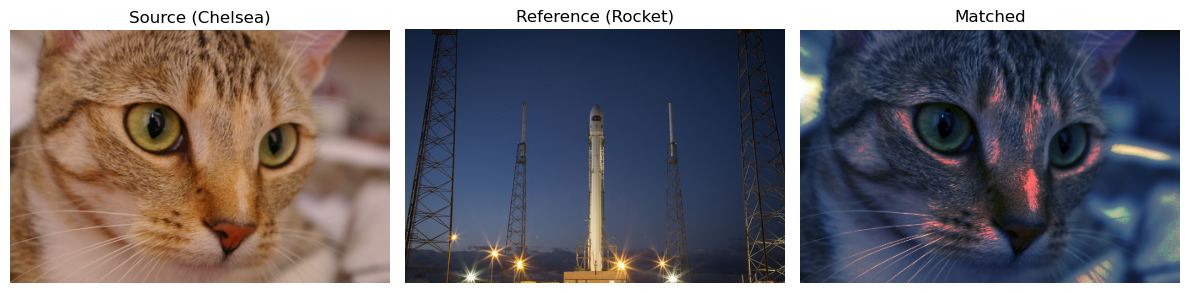

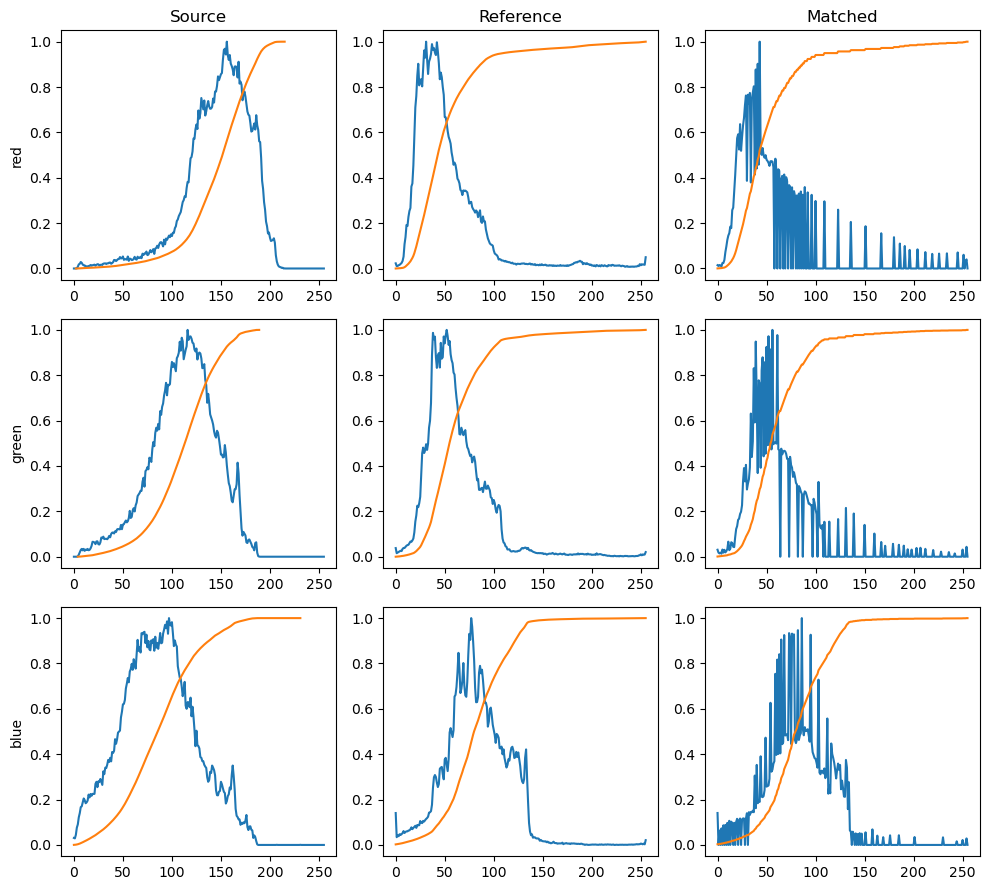

In [21]:
from skimage.exposure import match_histograms

reference = data.rocket()
image = data.chelsea()
matched = match_histograms(image, reference, channel_axis=-1)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
for aa in (ax1, ax2, ax3):
    aa.set_axis_off()
ax1.imshow(image);     ax1.set_title('Source (Chelsea)')
ax2.imshow(reference); ax2.set_title('Reference (Rocket)')
ax3.imshow(matched);   ax3.set_title('Matched')
plt.tight_layout()
plt.show()

# Per-channel histograms and CDFs
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 9))
for i, img_ in enumerate((image, reference, matched)):
    for c, c_color in enumerate(('red', 'green', 'blue')):
        img_hist, bins = exposure.histogram(img_[..., c], source_range='dtype')
        axes[c, i].plot(bins, img_hist / img_hist.max())
        img_cdf, bins = exposure.cumulative_distribution(img_[..., c])
        axes[c, i].plot(bins, img_cdf)
        axes[c, 0].set_ylabel(c_color)
axes[0, 0].set_title('Source')
axes[0, 1].set_title('Reference')
axes[0, 2].set_title('Matched')
plt.tight_layout()
plt.show()

**Observation:** After matching, the Chelsea image keeps its content (the cat) but takes on the color distribution of the rocket image. In each RGB channel the histogram and CDF of the matched image closely follow the reference (rocket) curves rather than the source curves.

## Conclusion
Thresholding converts an image to binary based on a cut-off; contrast stretching with percentile limits increases contrast and clips the tails; histogram equalization flattens the histogram to enhance global contrast; and histogram matching transfers the intensity distribution of a reference image onto another image.